In [1]:
import pandas as pd

from models.autoscaler.baseline import Baseline
from models.utils.parameters import *
from models.utils.visualization import LineChart

In [2]:
df_batch_task = pd.read_csv(SELECTED_BATCH_TASK_PATH)
df_batch_instance = pd.read_csv(SELECTED_BATCH_INSTANCE_PATH)

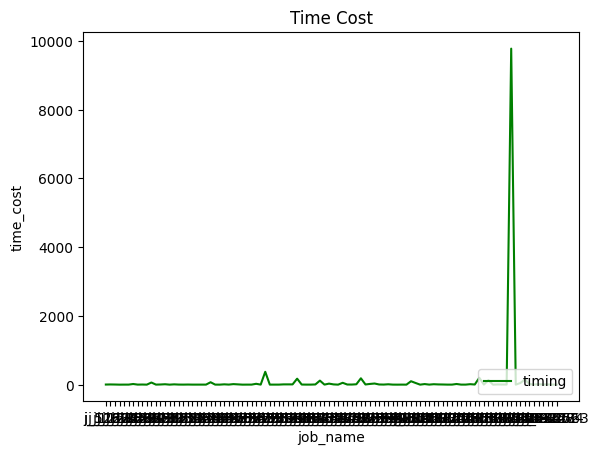

In [3]:
# 时间和空间成本对比
df_batch_instance_rows = df_batch_instance.shape[0]
i = 0
x_data, y_data = [], []
while i < df_batch_instance_rows:
    instance_nums = 0
    job_name = df_batch_instance.loc[i, 'job_name']
    while (i + instance_nums < df_batch_instance_rows) and (
            df_batch_instance.loc[i + instance_nums, 'job_name'] == job_name):
        instance_nums += 1
    job = df_batch_instance.loc[i: i + instance_nums - 1].copy()

    # =============== 对每个 job: Baseline 测试 ===============
    x_data.append(job_name)  # 添加 x 轴数据

    baseline = Baseline(job, i)

    time_cost = baseline.get_time_cost()
    y_data.append(time_cost)  # 添加 y 轴数据

    cpu_cost = baseline.get_cpu_cost()

    mem_cost = baseline.get_mem_cost()
    # =============== Baseline 测试 : 结束 ===============

    i += instance_nums

# 开始绘图
line_chart = LineChart(x_data, y_data, title="Time Cost", label="timing", x_label="job_name", y_label="time_cost")
line_chart.show()